In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [42]:
df = pd.read_csv('placement.csv')

In [43]:
df.head()

,cgpa,placement_exam_marks,placed
0,7.19,26.0,1
1,7.46,38.0,1
2,7.54,40.0,1
3,6.42,8.0,1
4,7.23,17.0,0


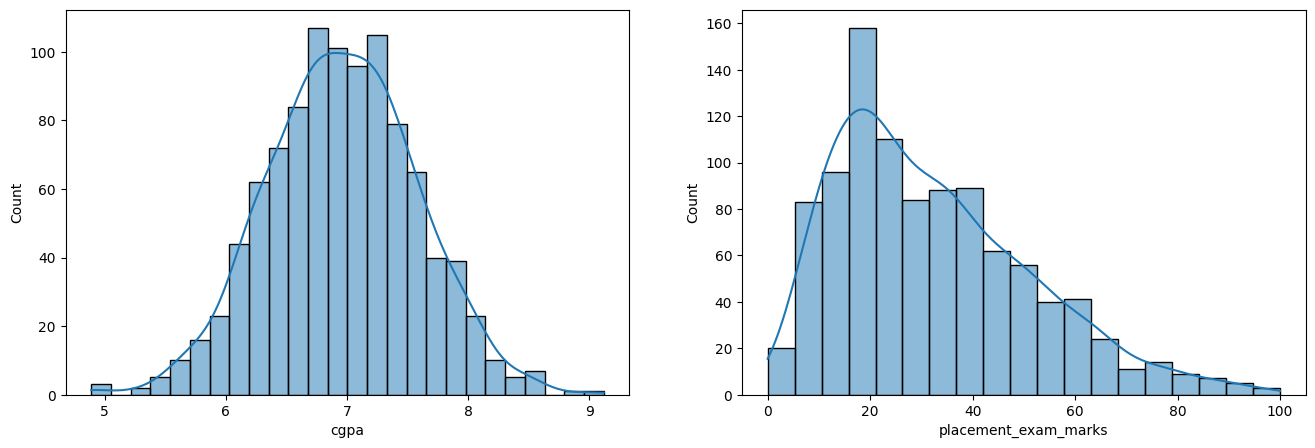

In [44]:
plt.figure(figsize=(16,5))

plt.subplot(1,2,1)
sns.histplot(df['cgpa'],kde=True)

plt.subplot(1,2,2)
sns.histplot(df['placement_exam_marks'],kde=True)

plt.show()

In [45]:
df['placement_exam_marks'].describe()

count    1000.000000
mean       32.225000
std        19.130822
min         0.000000
25%        17.000000
50%        28.000000
75%        44.000000
max       100.000000
Name: placement_exam_marks, dtype: float64

<Axes: xlabel='placement_exam_marks'>

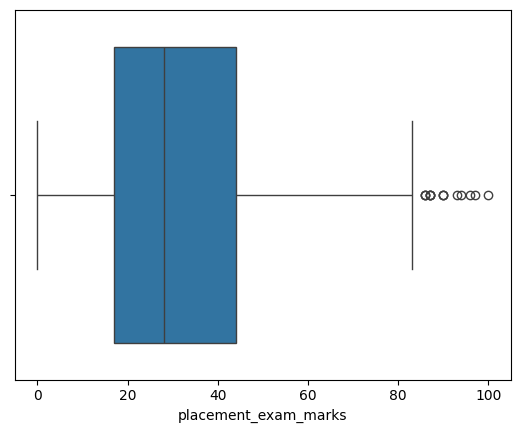

In [46]:
sns.boxplot(x=df['placement_exam_marks'])

In [47]:
# finding the IQR
percentile25 = df['placement_exam_marks'].quantile(0.25)
percentile75 = df['placement_exam_marks'].quantile(0.75)

In [48]:
percentile25

np.float64(17.0)

In [49]:
percentile75

np.float64(44.0)

In [50]:
iqr = percentile75 - percentile25

In [51]:
iqr

np.float64(27.0)

In [52]:
upper_limit = percentile75 + 1.5*iqr
lower_limit = percentile25 - 1.5*iqr

In [53]:
upper_limit

np.float64(84.5)

In [54]:
lower_limit

np.float64(-23.5)

In [55]:
# finding outliers

df[df['placement_exam_marks'] > upper_limit]

,cgpa,placement_exam_marks,placed
9,7.75,94.0,1
40,6.60,86.0,1
61,7.51,86.0,0
134,6.33,93.0,0
162,7.80,90.0,0
283,7.09,87.0,0
290,8.38,87.0,0
311,6.97,87.0,1
324,6.64,90.0,0
630,6.56,96.0,1


In [56]:
df[df['placement_exam_marks'] < lower_limit]

,cgpa,placement_exam_marks,placed


# trimming

In [57]:
new_df = df[df['placement_exam_marks'] < upper_limit]

In [58]:
new_df.shape

(985, 3)

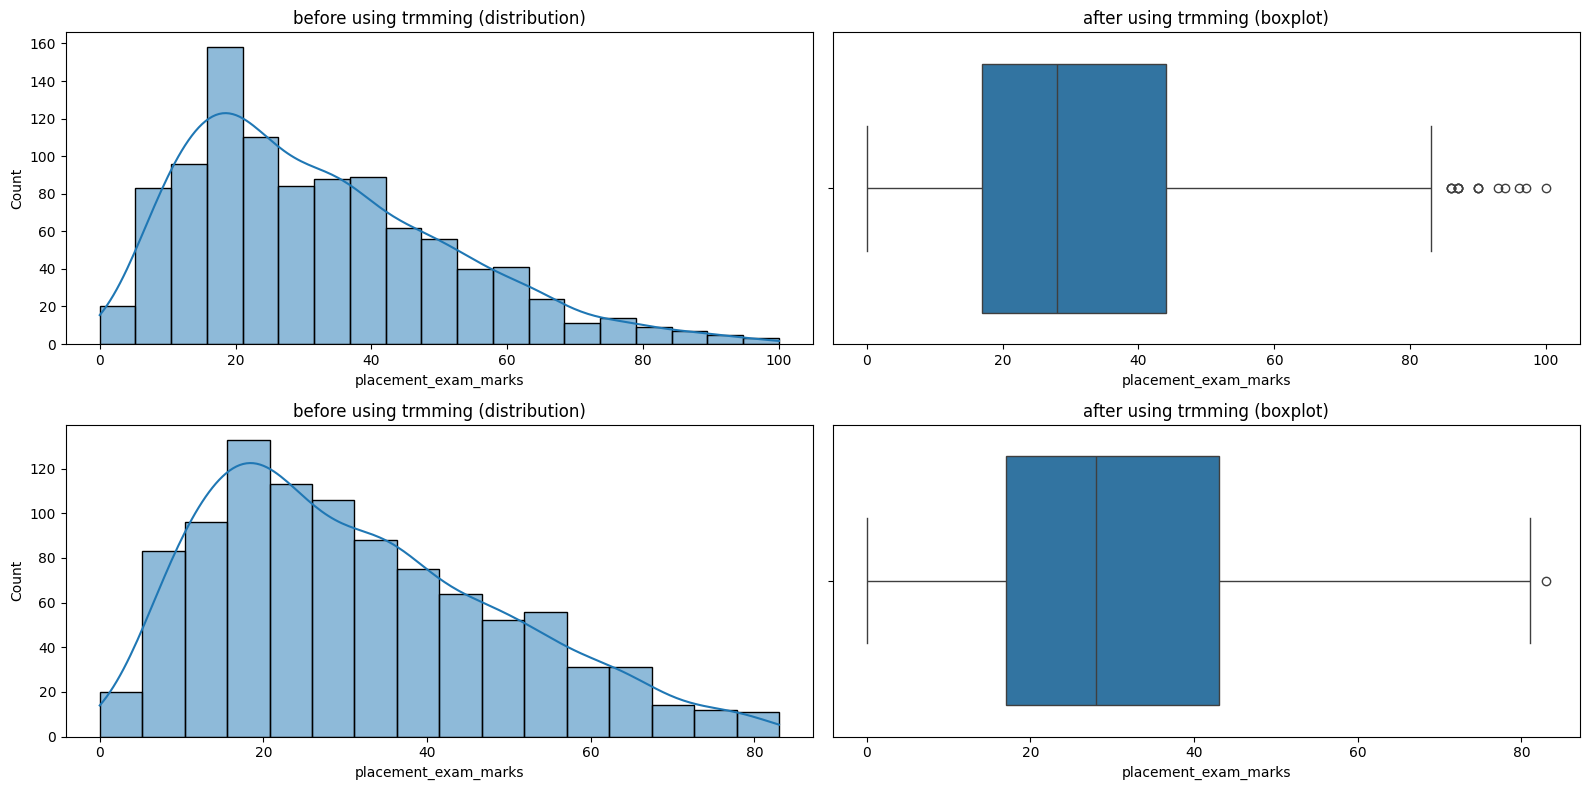

In [74]:
# comparing

plt.figure(figsize=(16,8))

# -- BEFORE TRIMMING --
plt.subplot(2,2,1)
plt.title('before using trmming (distribution)')
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
plt.title('after using trmming (boxplot)')
sns.boxplot(x=df['placement_exam_marks'])

# -- AFTER TRIMMING --
plt.subplot(2,2,3)
plt.title('before using trmming (distribution)')
sns.histplot(new_df['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
plt.title('after using trmming (boxplot)')
sns.boxplot(x=new_df['placement_exam_marks'])

plt.tight_layout() # subplot ke beech spacing sahi karne ke liye 
plt.show()

# capping

In [75]:
new_df_cap = df.copy()

new_df_cap['placement_exam_marks'] = np.where(
    new_df_cap['placement_exam_marks'] > upper_limit,
    upper_limit,
    np.where(
        new_df_cap['placement_exam_marks'] < lower_limit,
        lower_limit,
        new_df_cap['placement_exam_marks']
    ) 
)

In [76]:
new_df_cap.shape

(1000, 3)

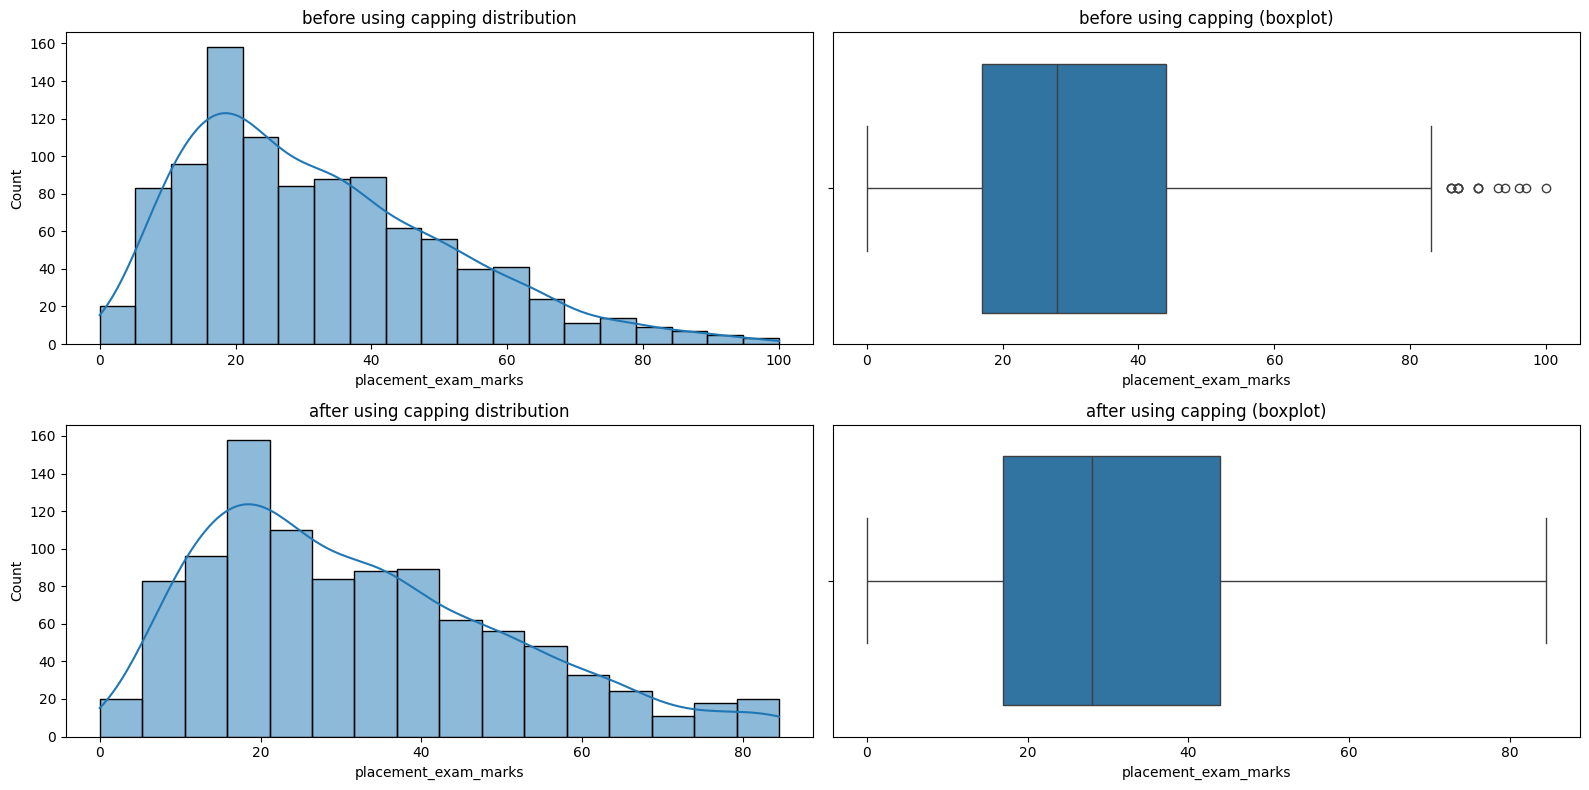

In [77]:
# comparing
plt.figure(figsize=(16,8))

# -- BEFORE CAPPING --
plt.subplot(2,2,1)
plt.title('before using capping distribution')
sns.histplot(df['placement_exam_marks'],kde=True)

plt.subplot(2,2,2)
plt.title('before using capping (boxplot)')
sns.boxplot(x=df['placement_exam_marks'])

# -- AFTER CAPPING --

plt.subplot(2,2,3)
plt.title('after using capping distribution')
sns.histplot(new_df_cap['placement_exam_marks'],kde=True)

plt.subplot(2,2,4)
plt.title('after using capping (boxplot)')
sns.boxplot(x=new_df_cap['placement_exam_marks'])

plt.tight_layout()
plt.show()